This code solves the Saint-Venant equations for a steady state flow over a bump. The Manning-Strickler equation is used for modelling the bed's flow resistance. The numerical solution to the Saint-Venant equations is compared to the solution to the Bresse equation.

This case corresponds to example 3.1 in Swashes. Source :
Olivier Delestre, Carine Lucas, Pierre-Antoine Ksinant Garcia, Frédéric Darboux, Christian Laguerre, et al.. SWASHES: Shallow Water Analytic Solutions for Hydraulic and Environmental Studies. 2025, [https://hal.inrae.fr/hal-02804975v4](https://hal.inrae.fr/hal-02804975v4)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from clawpack import riemann
from scipy.integrate import odeint
from IPython.display import HTML 
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'text.usetex': True,
    'text.latex.preamble': (
        r'\usepackage[T1]{fontenc}'
        r'\usepackage[utf8]{inputenc}'
        r'\usepackage{libertine}'
        r'\usepackage[libertine]{newtxmath}'
    ),
    'font.family': 'serif',
})


def DepthOfInterest(x,h0):
    """
    provides initial depth
    """
    import numpy as np
    
    if isinstance(x,(np.ndarray,list)):
        m = np.size(x)
        h = np.empty((m))
        for i in range(m):
            h[i] =  h0
    if isinstance(x,(float,int)):
        h =  h0
        
    return np.max(h), h

def flow_animation(claw,L):
    """ Create an animation of the clawpack solution"""
    import matplotlib.animation
    import numpy
    from math import ceil

    x = claw.frames[0].grid.dimensions[0].centers
    x_true = numpy.linspace(0., L , 500)

    h0  = claw.problem_data['initial_depth']
    h1, h = DepthOfInterest(x,h0)
    hmin = 0
    hm = 4 * h1

    fig = plt.figure()
    axes = plt.subplot(1, 1, 1)
    axes.set_xlabel(r'$x$', fontsize=14)
    axes.set_ylabel(r'$h(x, t)$', fontsize=14)
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((hmin, hm))
    axes.set_title(" ")
    axes.grid()
    text = axes.text(L/2, 0.9*hm, '')
 
    def init():
        axes.plot(x, bump(x), 'brown')
        computed_line, = axes.plot(x[0], bump(x[0])+claw.frames[0].q[0, :][0], 'blue')
        exact_line, = axes.plot(x_true[0], DepthOfInterest(x_true[0],h0)[1], 'k--')
        return  (computed_line, exact_line)
    
    computed_line, exact_line = init()
 
    def fplot(n):
        computed_line.set_data([x,], [bump(x)+claw.frames[n].q[0, :]])
        exact_line.set_data([x_true], [DepthOfInterest(x_true,h0)[1]])
        tt = claw.frames[n].t
        text.set_text(r'$t = ' + f'{tt:.2f}' + r'$ s')
        return (computed_line, exact_line)

    frames_to_plot = range(0, len(claw.frames))
    plt.close(fig)
    return matplotlib.animation.FuncAnimation(fig, fplot, frames=frames_to_plot, interval=100,
                                   blit=True, init_func=None, repeat=False)


def outlet_bc(state,dim,t,qbc,auxbc,num_ghost):
    """
    Outlet boundary condition adapting to the local flow regime.
    - Subcritical (Fr < 1): one characteristic enters (1-wave, lambda1 = u-c < 0).
      h imposed from outside (h = h_downstream), q computed from the 2-Riemann
      invariant of the last interior cell: r2 = u + 2*sqrt(g*h).
    - Supercritical (Fr > 1): both characteristics exit.
      Extrapolate (copy last interior cell).
    """
    g      = state.problem_data['grav']
    h_down = state.problem_data['h_downstream']
    
    hl  = qbc[0, -num_ghost-1]
    hul = qbc[1, -num_ghost-1]
    ul  = hul / hl
    Fr  = abs(ul) / np.sqrt(g * hl)
    
    if Fr < 1.0:
        r2 = ul + 2.0 * np.sqrt(g * hl)
        h_ghost = h_down
        u_ghost = r2 - 2.0 * np.sqrt(g * h_ghost)
        qbc[0, -num_ghost:] = h_ghost
        qbc[1, -num_ghost:] = u_ghost * h_ghost
    else:
        qbc[0, -num_ghost:] = hl  
        qbc[1, -num_ghost:] = hul 


def inlet_bc(state,dim,t,qbc,auxbc,num_ghost):
    """
    Inlet boundary condition adapting to the local flow regime.
    - Subcritical (Fr < 1): impose q, copy h from first interior cell.
    - Supercritical (Fr > 1): impose both h = h_upstream and q.
    """
    qIn  = state.problem_data['flow_rate']
    g    = state.problem_data['grav']
    h_up = state.problem_data['h_upstream']
    
    hr  = qbc[0, num_ghost]
    hur = qbc[1, num_ghost]
    ur  = hur / hr
    Fr  = abs(ur) / np.sqrt(g * hr)
    
    if Fr < 1.0:
        qbc[0, :num_ghost] = hr
        qbc[1, :num_ghost] = qIn
    else:
        qbc[0, :num_ghost] = h_up
        qbc[1, :num_ghost] = qIn

    
def bump(x):
    "Bump topography: b(x) = 0.2 - 0.05*(x-10)^2 for x in [8, 12], 0 otherwise"
    return np.where((x > 8) & (x < 12), 0.2 - 0.05*(x - 10)**2, 0.)

def initialisation(state):
    xc   = state.grid.x.centers
    h0   = state.problem_data["initial_depth"] 
    qIn  = state.problem_data['flow_rate']
    δ  = h0 - bump(xc)
    state.q[0, :] = np.where(δ>0,δ,0)
    state.q[1, :] = qIn

def topography(x, state):
    "Bump topography"
    return bump(x)
    
def step_euler(solver,state,dt):
    "source term for the shallow water equations with Strickler law"
    g = state.problem_data["grav"]
    K = state.problem_data["Strickler"]
    q = state.q
    depth = q[0,:]
    momentum = q[1,:]
    if K > 0:
        coef = g/K**2/depth**(7./3.)*abs(momentum)
    else:
        coef = 0
    q[1,:] = momentum / (1. + dt*coef)
    q[0,:] = depth

def setup(L, flow_rate, h0, h_upstream, h_downstream, K, mx, final_time, nb_output):
    from clawpack import pyclaw
    outdir = './_output'

    solver = pyclaw.ClawSolver1D(riemann.shallow_bathymetry_fwave_1D)
    solver.step_source  = step_euler
    solver.source_split = 1
    solver.limiters     = pyclaw.limiters.tvd.vanleer
    solver.fwave        = True
    solver.num_waves    = 2
    solver.num_eqn      = 2
    solver.order        = 2
    
    solver.bc_lower[0]     = pyclaw.BC.custom
    solver.user_bc_lower   = inlet_bc
    solver.bc_upper[0]     = pyclaw.BC.custom
    solver.user_bc_upper   = outlet_bc
    solver.aux_bc_lower[0] = pyclaw.BC.extrap
    solver.aux_bc_upper[0] = pyclaw.BC.extrap
    solver.max_steps       = 10000

    x      = pyclaw.Dimension(0, L, mx, name='x')
    domain = pyclaw.Domain(x)
    state  = pyclaw.State(domain, 2, 1)
    
    state.problem_data['grav']          = 9.81
    state.problem_data['dry_tolerance'] = 1e-6
    state.problem_data['sea_level']     = 0.
    state.problem_data['flow_rate']     = flow_rate
    state.problem_data["initial_depth"] = h0
    state.problem_data["h_upstream"]    = h_upstream
    state.problem_data["h_downstream"]  = h_downstream
    state.problem_data['Strickler']     = K

    initialisation(state)
    state.aux[0, :] = topography(state.grid.x.centers, state)
    
    claw = pyclaw.Controller()
    claw.verbosity        = 0
    claw.keep_copy        = True
    claw.tfinal           = final_time
    claw.num_output_times = nb_output
    claw.solution         = pyclaw.Solution(state, domain)
    claw.solver           = solver
    claw.write_aux_init   = True
    claw.outdir           = outdir

    return claw


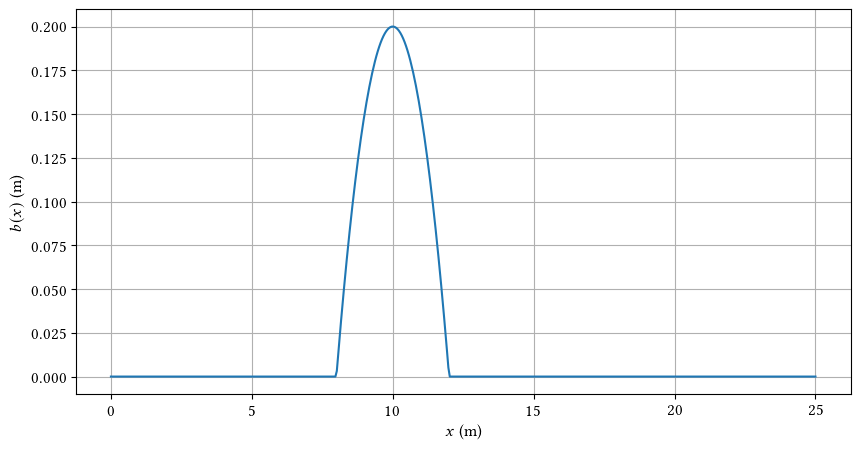

In [2]:
x_test = np.linspace(0, 25, 500)
plt.plot(x_test, bump(x_test))
plt.xlabel(r"$x$ (m)"); plt.ylabel(r"$b(x)$ (m)");  plt.grid()

# Simulation

In [6]:
g = 9.81
# Flume set-up: no flow
L = 25.; q0 = 0.; K = 0.;   
h0     = 0.5
h_up   = 0.5
h_down = 0.5

# Flume set-up: subcritical flow
L = 25.; q0 = 4.42; K = 0.;   
h0     = 2
h_up   = 0.5
h_down = 2

# Flume set-up: transcritical
L = 25.; q0 = 1.53; K = 0.;   
h0     = 0.66
h_up   = 0.5
h_down = h0

# Flume set-up: subcritical flow
L = 25.; q0 = 4.; K = 0.;   
h0     = 2
h_up   = h0
h_down = h0


# Flume set-up: sub and supercritical
L = 25.; q0 = 0.18; K = 0.;   
h0     = 0.33
h_up   = 0.5
h_down = h0



# Flume set-up:  supercritical
L = 25.; q0 = 4; K = 0.;   
h0     = 0.5
h_up   = h0
h_down = h0

# Flume set-up: sub and supercritical
L = 25.; q0 = 4; K = 0.;   
h0     = 1
h_up   = h0
h_down = h0

# Computation
mx=500; tf = 100.; nbo = 100# Flow features

Fr_0 = q0/np.sqrt(g*h0**3)
print(f"Froude number at the inlet: {Fr_0:0.2f}")
print(f"Specific head at the inlet: {(q0/h0)**2/9.81/2+h0:0.2f} m")
h_c = (q0**2/g)**(1/3)



print(f"Critical depth: {h_c:0.2f} m")
g   = 9.81
z_m = 0.2
z_max = h0*(1-1.5*Fr_0**(2/3)+0.5*Fr_0**2)
print(f"Maximum obstacle size: {z_max:0.2f} m (ζ = {z_max/h0:.2f})")
if z_m>z_max: 
    print(" * Obstacle too large")
    head_m = (q0/h_c)**2/g/2+h_c+z_m
    head_g = (q0/h0)**2/g/2+h0 
    print(f" * Minimum head required to spill over the bump: {head_m:0.2f} m")
    print(f" * Head required in the ghost cell: {head_g:0.2f} m")
    coeff = [1,-head_m,0,q0**2/2/g]
    h_new = np.roots(coeff)[0]
    print(f" * Jump formed at the inlet. New depth at the inlet: {h_new:0.2f} m")
else:
    print(" * upstream depth larger than bump height")



Froude number at the inlet: 1.28
Specific head at the inlet: 1.82 m
Critical depth: 1.18 m
Maximum obstacle size: 0.05 m (ζ = 0.05)
 * Obstacle too large
 * Minimum head required to spill over the bump: 1.97 m
 * Head required in the ghost cell: 1.82 m
 * Jump formed at the inlet. New depth at the inlet: 1.68 m


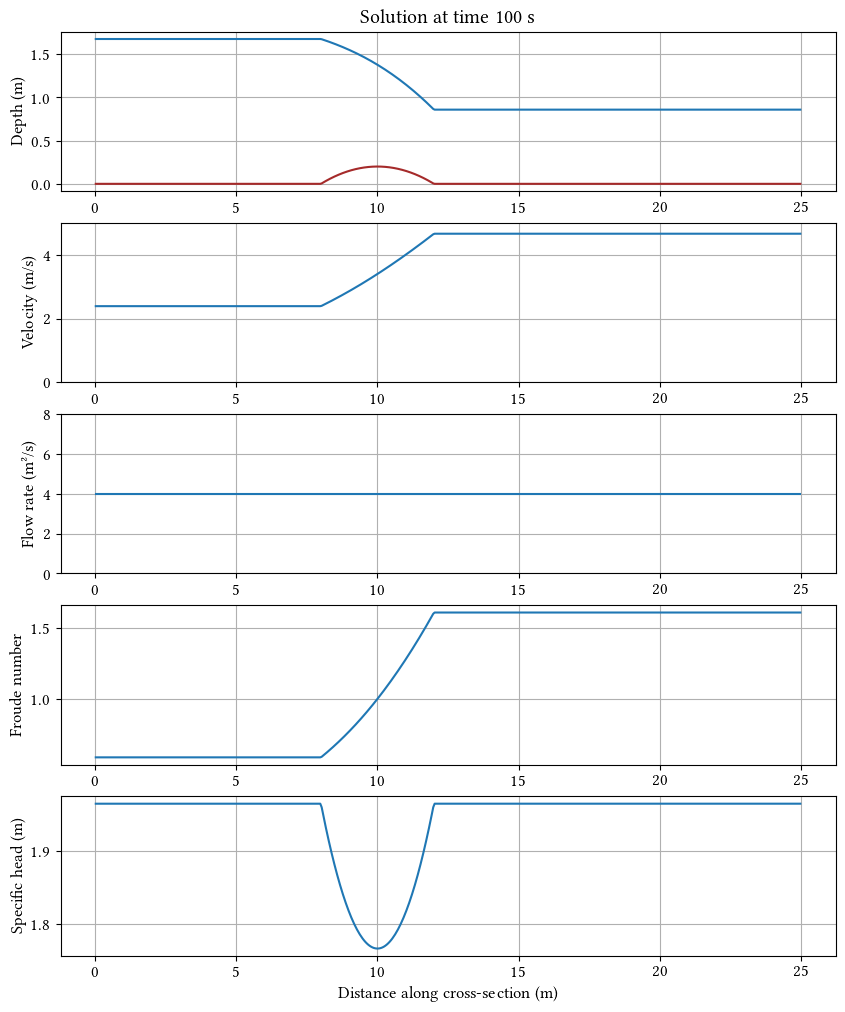

In [7]:
#setup 
claw=setup(L,q0,h0,h_up,h_down,K,mx,tf,nbo)
claw.run()


h = claw.frames[-1].q[0, :]
q = claw.frames[-1].q[1, :]
u = q/h
froude = u/np.sqrt(g*h)
head   = u**2/2/g+h

# --- Setup of the figure ---
fig, ((ax, axu,axq,ax_fr,ax_Hs) ) = plt.subplots(5, 1)
fig.set_figheight(12)
fig.set_figwidth(10)
#ax.set_xlabel("Distance along cross-section (m)")
ax.set_ylabel("Depth (m)")
ax.grid()
x = claw.frames[0].grid.dimensions[0].centers
ax.plot(x,bump(x)+h)
ax.plot(x,bump(x),'brown')

#axu.set_xlabel("Distance along cross-section (m)")
axu.set_ylabel("Velocity (m/s)")
axu.grid()

axu.plot(x,u)
axu.set_ylim([0,1+int(u.max())])

axq.set_ylabel("Flow rate (m²/s)")
axq.grid()
 
axq.plot(x,q )
axq.set_ylim([0,2*q0])

#ax_fr.set_xlabel("Distance along cross-section (m)")
ax_fr.set_ylabel("Froude number  ")
ax_fr.grid()
ax_fr.plot(x,froude)

ax_Hs.set_xlabel("Distance along cross-section (m)")
ax_Hs.set_ylabel("Specific head (m) ")
ax_Hs.grid()
head = head
ax_Hs.plot(x,head)

ax.set_title(f"Solution at time {claw.frames[-1].t:.0f} s")
fig.savefig("solution2.png",dpi=300,bbox_inches='tight')

## Grid of results (clawpack)

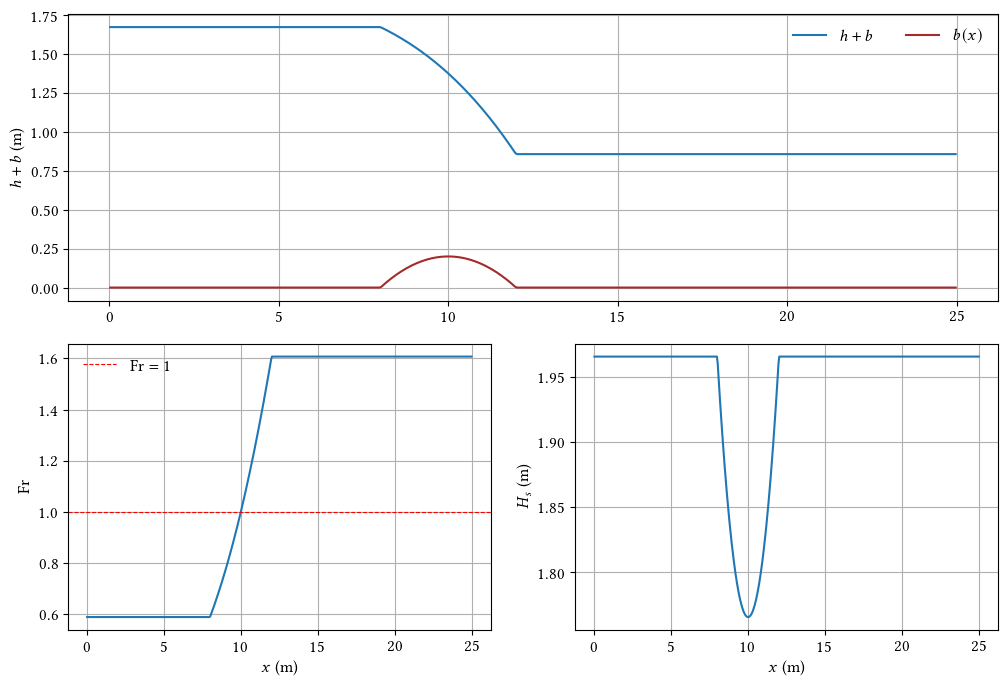

In [8]:
# Données du dernier frame
frame = claw.frames[-1]
x     = frame.state.grid.x.centers
b     = frame.aux[0, :]
h     = frame.q[0, :]
q_num = frame.q[1, :]
u     = q_num / h
froude = u / np.sqrt(g * h)
head   = u**2 / (2*g) + h

# --- Mosaïque 2×2  ---
fig = plt.figure(figsize=(12, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.15)

ax1 = fig.add_subplot(gs[0, :])   # ligne 1 
ax2 = fig.add_subplot(gs[1, 0])   # ligne 2, colonne 1
ax3 = fig.add_subplot(gs[1, 1])   # ligne 2, colonne 2

# --- Hauteur d'eau ---
ax1.plot(x, h + b, label=r'$h + b$')
ax1.plot(x, b, color='brown', label=r'$b(x)$')
ax1.set_ylabel(r'$h + b$ (m)')
ax1.legend(ncol=2, frameon=False)
ax1.grid()

# --- Nombre de Froude ---
ax2.plot(x, froude)
ax2.axhline(1, color='r', linestyle='--', linewidth=0.8, label=r'$\mathrm{Fr} = 1$')
ax2.set_xlabel(r'$x$ (m)')
ax2.set_ylabel(r'Fr')
ax2.legend(frameon=False)
ax2.grid()

# --- Charge spécifique ---
ax3.plot(x, head)
ax3.set_xlabel(r'$x$ (m)')
ax3.set_ylabel(r'$H_s$ (m)')
ax3.grid()

plt.show()
fig.savefig("solution3.png",dpi=300,bbox_inches='tight')

In [9]:
print(f"max flow rate: {claw.frames[1].q[1, :].max():.2f} m²/s at time {claw.frames[1].t} s")
print(f"max flow depth: {claw.frames[1].q[0, :].max():.2f} m")

max flow rate: 4.71 m²/s at time 1.0 s
max flow depth: 1.26 m


## Animation

In [10]:
# Flow depth animation
anim = flow_animation(claw,L)
HTML(anim.to_jshtml())


In [189]:
anim.save("animation-depth.mp4",writer="ffmpeg",fps = 5)

## Comparison clawpack and Bernoulli

Obstacle too large: E_amont = 1.815 m < E_min = 1.966 m
  → Bernoulli's solution computed with c = E_min = 1.966 m


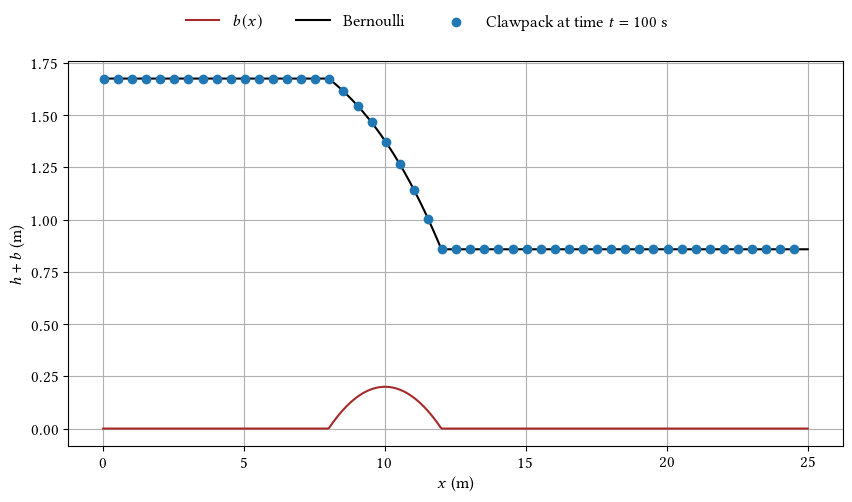

In [11]:
def bernoulli_solution(x_array, q, c, x_ref, h_start):
    """
    Bernoulli solution h(x) by continuity from the reference point.
    Solves  h + b(x) + q²/(2g·h²) = c.
    Traverses x_array from x_ref outward, always picking the real positive root
    closest to the previous value. Returns np.nan where no real solution exists.
    """
    g     = 9.81
    h_out = np.full(len(x_array), np.nan)
    h_prev = h_start
    for i in np.argsort(np.abs(x_array - x_ref)):
        roots    = np.roots([1., bump(x_array[i]) - c, 0., q**2 / (2*g)])
        real_pos = roots[np.isclose(roots.imag, 0, atol=1e-8) & (roots.real > 0)].real
        if len(real_pos) == 0:
            continue
        h        = float(real_pos[np.argmin(np.abs(real_pos - h_prev))])
        h_out[i] = h
        h_prev   = h
    return h_out


def bernoulli_h_flat(q, c, regime='sub'):
    """
    Sub- or supercritical root of  h + q²/(2g·h²) = c  at b = 0.
    regime='sub'   → larger root (h > hc)
    regime='super' → smaller root (h < hc)
    """
    g  = 9.81
    hc = (q**2 / g)**(1/3)
    roots    = np.roots([1., -c, 0., q**2 / (2*g)])
    real_pos = roots[np.isclose(roots.imag, 0, atol=1e-8) & (roots.real > 0)].real
    if regime == 'sub':
        cands = real_pos[real_pos >= hc]
        return float(cands.max()) if len(cands) > 0 else float(real_pos.max())
    else:
        cands = real_pos[real_pos <= hc]
        return float(cands.min()) if len(cands) > 0 else float(real_pos.min())


# --- Comparison with the Bernoulli solution ---
fig, ax = plt.subplots(figsize=(10,5))
ax.set_xlabel(r'$x$ (m)')
ax.set_ylabel(r'$h + b$ (m)')
ax.grid()

x_plot = np.linspace(0, L, mx)
ax.plot(x_plot, bump(x_plot), 'brown', label=r'$b(x)$')


def add_true_solution(claw, density=10):
    """Plot the numerical solution (last frame)."""
    frame = claw.frames[-1]
    b = frame.aux[0, :]
    h = frame.q[0, :]
    x = frame.state.grid.x.centers
    ax.scatter(x[::density], b[::density] + h[::density],
               label=rf"Clawpack at time $t={frame.t:.0f}$ s", zorder=5)


def add_bernoulli(L, q, h_down, mx):
    """
    Bernoulli solution for a sub- or supercritical case (no critical transition).
    Traverses from x = L with h = h_down.
    """
    g = 9.81
    x = np.linspace(0, L, mx)
    c = h_down + bump(L) + q**2 / (2*g*h_down**2)
    h = bernoulli_solution(x, q, c, x_ref=L, h_start=h_down)
    ax.plot(x, bump(x) + h, '-k', label='Bernoulli')


def add_bernoulli_transcritical(L, q, c_up, mx):
    """
    Bernoulli solution for a transcritical case (flow passes through critical
    at the bump crest).  Single energy level c_up, split at the crest:

      x ≤ x_crest : subcritical branch, traversed from x = 0  (sub root at b=0)
      x > x_crest : supercritical branch, traversed from x = L (super root at b=0)

    Splitting avoids the ambiguity at the critical point where the continuity
    algorithm cannot reliably choose the correct branch.
    """
    g = 9.81
    x = np.linspace(0, L, mx)

    # Locate the bump crest
    x_crest = x[np.argmax(bump(x))]

    h_full = np.full(len(x), np.nan)

    # Left part: subcritical, anchor at x = 0 with sub root at b = 0
    h_sub0  = bernoulli_h_flat(q, c_up, regime='sub')
    mask_up = x <= x_crest
    h_full[mask_up] = bernoulli_solution(x[mask_up], q, c_up,
                                         x_ref=0, h_start=h_sub0)

    # Right part: supercritical, anchor at x = L with super root at b = 0
    h_sup0  = bernoulli_h_flat(q, c_up, regime='super')
    mask_dn = x > x_crest
    h_full[mask_dn] = bernoulli_solution(x[mask_dn], q, c_up,
                                         x_ref=L, h_start=h_sup0)

    ax.plot(x, bump(x) + h_full, '-k', label=f'Bernoulli')


# --- Choose the right Bernoulli function ---
g     = 9.81
hc    = (q0**2 / g)**(1/3)
b_max = 0.2
E_amont = q0**2 / (2*g*h0**2) + h0    # specific energy at the inlet
E_min   = 1.5*hc + b_max               # minimum energy to pass the bump (critical at crest)

if E_min > E_amont:
    # Obstacle too high: a transient jump near the inlet raises the energy to E_min.
    # In steady state, the entire flow has energy c_up = E_min.
    print(f"Obstacle too large: E_amont = {E_amont:.3f} m < E_min = {E_min:.3f} m")
    print(f"  → Bernoulli's solution computed with c = E_min = {E_min:.3f} m")
    add_bernoulli_transcritical(L, q0, c_up=E_min, mx=mx)
else:
    add_bernoulli(L, q0, h_down, mx)

add_true_solution(claw)
fig.legend(loc="upper center", ncol=3, frameon=False)
plt.show()
fig.savefig("steady-state_comparison-Bresse-StV.png", dpi=300, bbox_inches='tight')


## Bernoulli solution (alone)

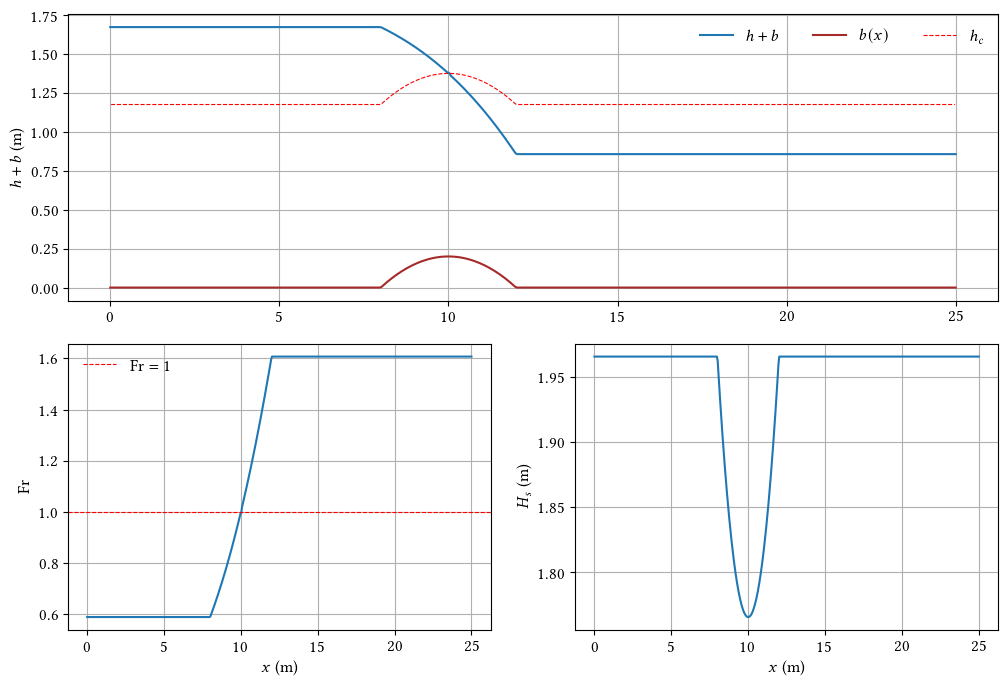

In [12]:

hc    = (q0**2 / g)**(1/3)
b_max = 0.2
E_amont = q0**2 / (2*g*h0**2) + h0
E_min   = 1.5*hc + b_max

x_b = np.linspace(0, L, mx)
b_b = bump(x_b)

# --- Solution de Bernoulli ---
if E_min > E_amont:
    # Cas transcritique : obstacle trop grand, un ressaut forme à l'entrée
    c_up    = E_min
    x_crest = x_b[np.argmax(b_b)]
    h_b     = np.full(len(x_b), np.nan)

    # Branche subcritique (x ≤ sommet)
    h_sub0       = bernoulli_h_flat(q0, c_up, regime='sub')
    mask_up       = x_b <= x_crest
    h_b[mask_up]  = bernoulli_solution(x_b[mask_up], q0, c_up, x_ref=0,   h_start=h_sub0)

    # Branche supercritique (x > sommet)
    h_sup0        = bernoulli_h_flat(q0, c_up, regime='super')
    mask_dn        = x_b >  x_crest
    h_b[mask_dn]  = bernoulli_solution(x_b[mask_dn], q0, c_up, x_ref=L,   h_start=h_sup0)
else:
    # Cas simple (sub ou supercritique) : une seule énergie depuis l'aval
    c   = h_down + b_b[-1] + q0**2 / (2*g*h_down**2)
    h_b = bernoulli_solution(x_b, q0, c, x_ref=L, h_start=h_down)

u_b      = q0 / h_b
froude_b = u_b / np.sqrt(g * h_b)
head_b   = u_b**2 / (2*g) + h_b   # charge spécifique (constante pour K=0)

# --- Mosaïque 2×2 ---
fig = plt.figure(figsize=(12, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.15)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

ax1.plot(x_b, h_b + b_b, label=r'$h + b$')
ax1.plot(x_b, b_b, color='brown', label=r'$b(x)$')
ax1.set_ylabel(r'$h + b$ (m)')
ax1.plot(x,hc+bump(x), color='r', linestyle='--', linewidth=0.8, label=r'$h_c$')
#ax1.set_title(r'Solution de Bernoulli ($q = ' + f'{q0}' + r'$ m$^2$/s, $h_0 = ' + f'{h0}' + r'$ m)')
ax1.legend(ncol=3, frameon=False)
ax1.grid()

ax2.plot(x_b, froude_b)
ax2.axhline(1, color='r', linestyle='--', linewidth=0.8, label=r'$\mathrm{Fr} = 1$')
ax2.set_xlabel(r'$x$ (m)')
ax2.set_ylabel(r'Fr')
ax2.legend(frameon=False)
ax2.grid()

ax3.plot(x_b, head_b)
ax3.set_xlabel(r'$x$ (m)')
ax3.set_ylabel(r'$H_s$ (m)')
ax3.grid()

plt.show()

fig.savefig("depth-froude-hs-Bernoulli.png",dpi=300,bbox_inches = 'tight')

# Animation flow rate and velocity

In [13]:
def flow_animation_rate(claw):
    """ 
    Animation for the flow rate
    """
    import matplotlib.animation
    import numpy
    from math import ceil

    index = np.size(claw.frames)-1
    qm = ceil(max(claw.frames[index].q[1,:])) *1.2
    #qm = 1.25
     
    x = claw.frames[0].grid.dimensions[0].centers
    x_true = numpy.linspace(0., L , 500)
    
    h0  = claw.problem_data['initial_depth']
    
    qn = claw.problem_data['flow_rate']
     
    fig = plt.figure()
    axes = plt.subplot(1, 1, 1)
    
    axes.set_xlabel(r'$x$',fontsize=14)
    axes.set_ylabel(r'$q(x, t)$',fontsize=14)
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim(( 0.8, qm))
    axes.set_title(" ")
    text = axes.text(L/2, 0.9*qm , '')
 
    def init():
 

        computed_line, = axes.plot(x[0], claw.frames[0].q[1, :][0], 'r')
        exact_line, = axes.plot(x_true[0], qn, 'k--')
        return  (computed_line, exact_line)
    
    computed_line, exact_line = init()
 
    
    def fplot(n):
        computed_line.set_data([x,], [claw.frames[n].q[1, :]])
        exact_line.set_data([x_true], [np.ones(np.size(x_true))*qn])
        tt = claw.frames[n].t
        val = f'{tt:.2f}'
        text.set_text(r'$ t = {} $ s'.format(val))
        #text.set_text(rf't = {tt:.2f} s' )
        return (computed_line, exact_line)

    frames_to_plot = range(0, len(claw.frames))
    plt.close(fig)
    return matplotlib.animation.FuncAnimation(fig, fplot, frames=frames_to_plot, interval=100,
                                   blit=True, init_func=None, repeat=False)


from IPython.display import HTML 
anim = flow_animation_rate(claw)
HTML(anim.to_jshtml())

In [15]:
def flow_animation_velocity(claw):
    """animation for the flow velocity"""
    import matplotlib.animation
    import numpy
    from math import ceil, floor

    index = np.size(claw.frames)-1
    qm = (max(claw.frames[index].q[1,:])) 
    hm = (min(claw.frames[index].q[0,:])) 
    x = claw.frames[0].grid.dimensions[0].centers
    x_true = numpy.linspace(0., L , 500)
    
    h0  = claw.problem_data['initial_depth']
    
    
    um = qm/hm*1.2

    fig = plt.figure()
    axes = plt.subplot(1, 1, 1)
  
    axes.set_xlabel(r'$x$',fontsize=14)
    axes.set_ylabel(r'$u(x, t)$',fontsize=14)
    axes.set_xlim((x[0], x[-1]))
    #axes.set_ylim(( 0, um))
    axes.set_title(" ")
    text = axes.text(L/2, 0.9*um , '')
 
    def init():
        axes.set_xlim((x[0], x[-1]))
        axes.set_ylim((0,um))

        computed_line, = axes.plot(x[0], claw.frames[0].q[1, :][0]/claw.frames[0].q[0, :][0], 'r')
        exact_line, = axes.plot(x_true[0], um, 'k--')
        return  (computed_line, exact_line)
    
    computed_line, exact_line = init()
 
    
    def fplot(n):
        computed_line.set_data([x,], [ claw.frames[n].q[1, :]/claw.frames[n].q[0, :] ])
        exact_line.set_data([x_true], [ um*np.ones(np.size(x_true)) ])
        tt = claw.frames[n].t
        val = f'{tt:.2f}'
        text.set_text(r'$ t = {} $ s'.format(val))
        #text.set_text(rf't = {tt:.2f} s' )
        return (computed_line, exact_line)

    frames_to_plot = range(0, len(claw.frames))
    plt.close(fig)
    return matplotlib.animation.FuncAnimation(fig, fplot, frames=frames_to_plot, interval=100,
                                   blit=True, init_func=None, repeat=False)



anim = flow_animation_velocity(claw)
HTML(anim.to_jshtml())